In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

from sango import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from sango.model import PSP

from sango.backend import SimSTACS

In [2]:
# We need to use our own models for this
# these are cross-referenced from STACS
from sango.model import Neuron, Synapse, shared
from dataclasses import dataclass, field

@dataclass
class Izhi(Neuron):
    model: str = 'Izhi'
    a: float = shared(0.02)
    b: float = shared(0.2)
    c: float = shared(-65.0)
    d: float = shared(8.0)
    thal_rate: float = shared(1.0)
    thal_ampl: float = shared(20.0)
    psn_rate: float = shared(0.0)
    v: float = -65.0
    u: float = -13.0

@dataclass
class STDP(Synapse):
    model: str = 'STDP'
    w_max: float = shared(10.0)
    w_min: float = shared(0.0)
    A_pos: float = shared(0.1)
    A_neg: float = shared(-0.12)
    tau_pos: float = shared(20.0)
    tau_neg: float = shared(20.0)
    wd_const: float = shared(0.01)
    wd_lambda: float = shared(0.9)
    delay: float = 1.0
    weight: float = 1.0

# Matching class information in STACS models
polynet_registry = {'Izhi': {'graph_type': 'node',
                             'model_type': 'izhi_neuron_clamp',
                             'param': {'a':          {'dsl': 'a',         'default': 0.02},
                                       'b':          {'dsl': 'b',         'default': 0.2},
                                       'c':          {'dsl': 'c',         'default': -65.0},
                                       'd':          {'dsl': 'd',         'default': 8.0},
                                       'thal_rate':  {'dsl': 'thal_rate', 'default': 1.0},
                                       'thal_ampl':  {'dsl': 'thal_ampl', 'default': 20.0},
                                       'psn_rate':   {'dsl': 'psn_rate',  'default': 0.0}},
                             'state': {'v':          {'dsl': 'v',         'default': -65.0},
                                       'u':          {'dsl': 'u',         'default': -13.0},
                                       'I_syn':      {'dsl': None,        'default': 0.0},
                                       'I_app':      {'dsl': None,        'default': 0.0},
                                       'I_clamp':    {'dsl': None,        'default': 0.0}}},
                    'STDP': {'graph_type': 'edge',
                             'model_type': 'stdp_synapse',
                             'param': {'w_max':      {'dsl': 'w_max',     'default': 10.0},
                                       'w_min':      {'dsl': 'w_min',     'default': 0.0},
                                       'A_pos':      {'dsl': 'A_pos',     'default': 0.1},
                                       'A_neg':      {'dsl': 'A_neg',     'default': -0.12},
                                       'tau_pos':    {'dsl': 'tau_pos',   'default': 20.0},
                                       'tau_neg':    {'dsl': 'tau_neg',   'default': 20.0},
                                       'wd_const':   {'dsl': 'wd_const',  'default': 0.01},
                                       'wd_lambda':  {'dsl': 'wd_lambda', 'default': 0.9},
                                       't_update':   {'dsl': None,        'default': 1000.0}},
                             'state': {'delay':      {'dsl': 'delay',     'default': 1.0, 'rep': 'tick'},
                                       'weight':     {'dsl': 'weight',    'default': 1.0},
                                       'wdelta':     {'dsl': None,        'default': 0.0},
                                       'ptrace':     {'dsl': None,        'default': 0.0},
                                       'ntrace':     {'dsl': None,        'default': 0.0},
                                       'ptlast':     {'dsl': None,        'default': 0.0, 'rep': 'tick'},
                                       'ntlast':     {'dsl': None,        'default': 0.0, 'rep': 'tick'}}}
                    }

In [3]:
# Helper function for edges (use CSA for this?)
def get_edges(prob, num_s, num_t, same):
    edges = set()
    assert 0.0 <= prob <= 1.0, f"Probability {prob} is not between 0.0 and 1.0"
    num = int(prob * num_s * num_t)
    while len(edges) < num:
        s = np.random.randint(num_s)
        t = np.random.randint(num_t)
        # no self connections
        if (not same) or (s != t):
            edges.add((s,t))
    return list(edges)

In [4]:
net = Network()

# Neuron parameterization
ex_neuron = Izhi()
ex_neuron.a = 0.02
ex_neuron.b = 0.2
ex_neuron.c = -65.0
ex_neuron.d = 8.0
ex_neuron.thal_rate = 1.0

in_neuron = Izhi()
in_neuron.a = 0.1
in_neuron.b = 0.2
in_neuron.c = -65.0
in_neuron.d = 2.0
in_neuron.thal_rate = 1.0

# E-I network ratio
res_e_size = 800
res_i_size = 200

# Connection probabilities
e_prob = 0.1
i_prob = 0.125

# Populations
net.res_e = NodeGroup(ex_neuron, res_e_size)
net.res_i = NodeGroup(in_neuron, res_i_size)

# Connections
ee_edges = get_edges(e_prob, res_e_size, res_e_size, True)
ee_delays = np.random.choice(np.array(range(1,21)), len(ee_edges))
net.ee = EdgeGroup(net.res_e, net.res_e, STDP(weight=6.0),
                   edges=ee_edges, delay=ee_delays)

ei_edges = get_edges(e_prob, res_e_size, res_i_size, True)
ei_delays = np.random.choice(np.array(range(1,21)), len(ei_edges))
net.ei = EdgeGroup(net.res_e, net.res_i, STDP(weight=6.0),
                   edges=ei_edges, delay=ei_delays)

net.ie = EdgeGroup(net.res_i, net.res_e, PSP(weight=-5.0),
                    get_edges(i_prob, res_i_size, res_e_size, False))

# Build network
net.build()
print(net)

info: flattening network topology
(node) res_e
(node) res_i
(edge) ee: (node) res_e -> (node) res_e
(edge) ei: (node) res_e -> (node) res_i
(edge) ie: (node) res_i -> (node) res_e


In [5]:
# We can simulate this in STACS
sim = SimSTACS(net, verbose=True)

# Add the polynet model registry information to the default
sim.model_registry.update(polynet_registry)

# Update the recording information
sim.record_spec['probes'].append({'name': 'Izhi',
                                  'state': 'v',
                                  'period': 100.0})
sim.record_spec['probes'].append({'name': 'STDP',
                                  'state': 'weight',
                                  'period': 1000.0})

# Compile to SNN-dCSR
sim.compile(netparts=4)

Compile time: 0.6124486249973415


In [6]:
# Run the network for 1 minute
sim.run(60000.0)

/Users/felwang/Documents/Projects/STACS/stacs/charmrun +p4 /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml

Running as 4 OS processes:  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
charmrun> mpirun -np 4  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
Charm++> Running on MPI version: 4.1
Charm++> level of thread support used: -1 (desired: 0)
Charm++> Running in non-SMP mode: 4 processes (PEs)
Converse/Charm++ Commit ID: v70000
Charm++ built without optimization.
Do not use for performance benchmarking (build with --with-production to do so).
Charm++ built with internal error checking enabled.
Do not use for performance benchmarking (build without --enable-error-checking to do so).
Isomalloc> Synchronized global address space.
CharmLB> Load balancer assumes all CPUs are same.
Charm++> Running on 1 hosts (1 sockets x 12 cores x 1 PUs = 12-way SMP)
Charm++> cpu topology info is gathered in 0.008 seconds.

Sim

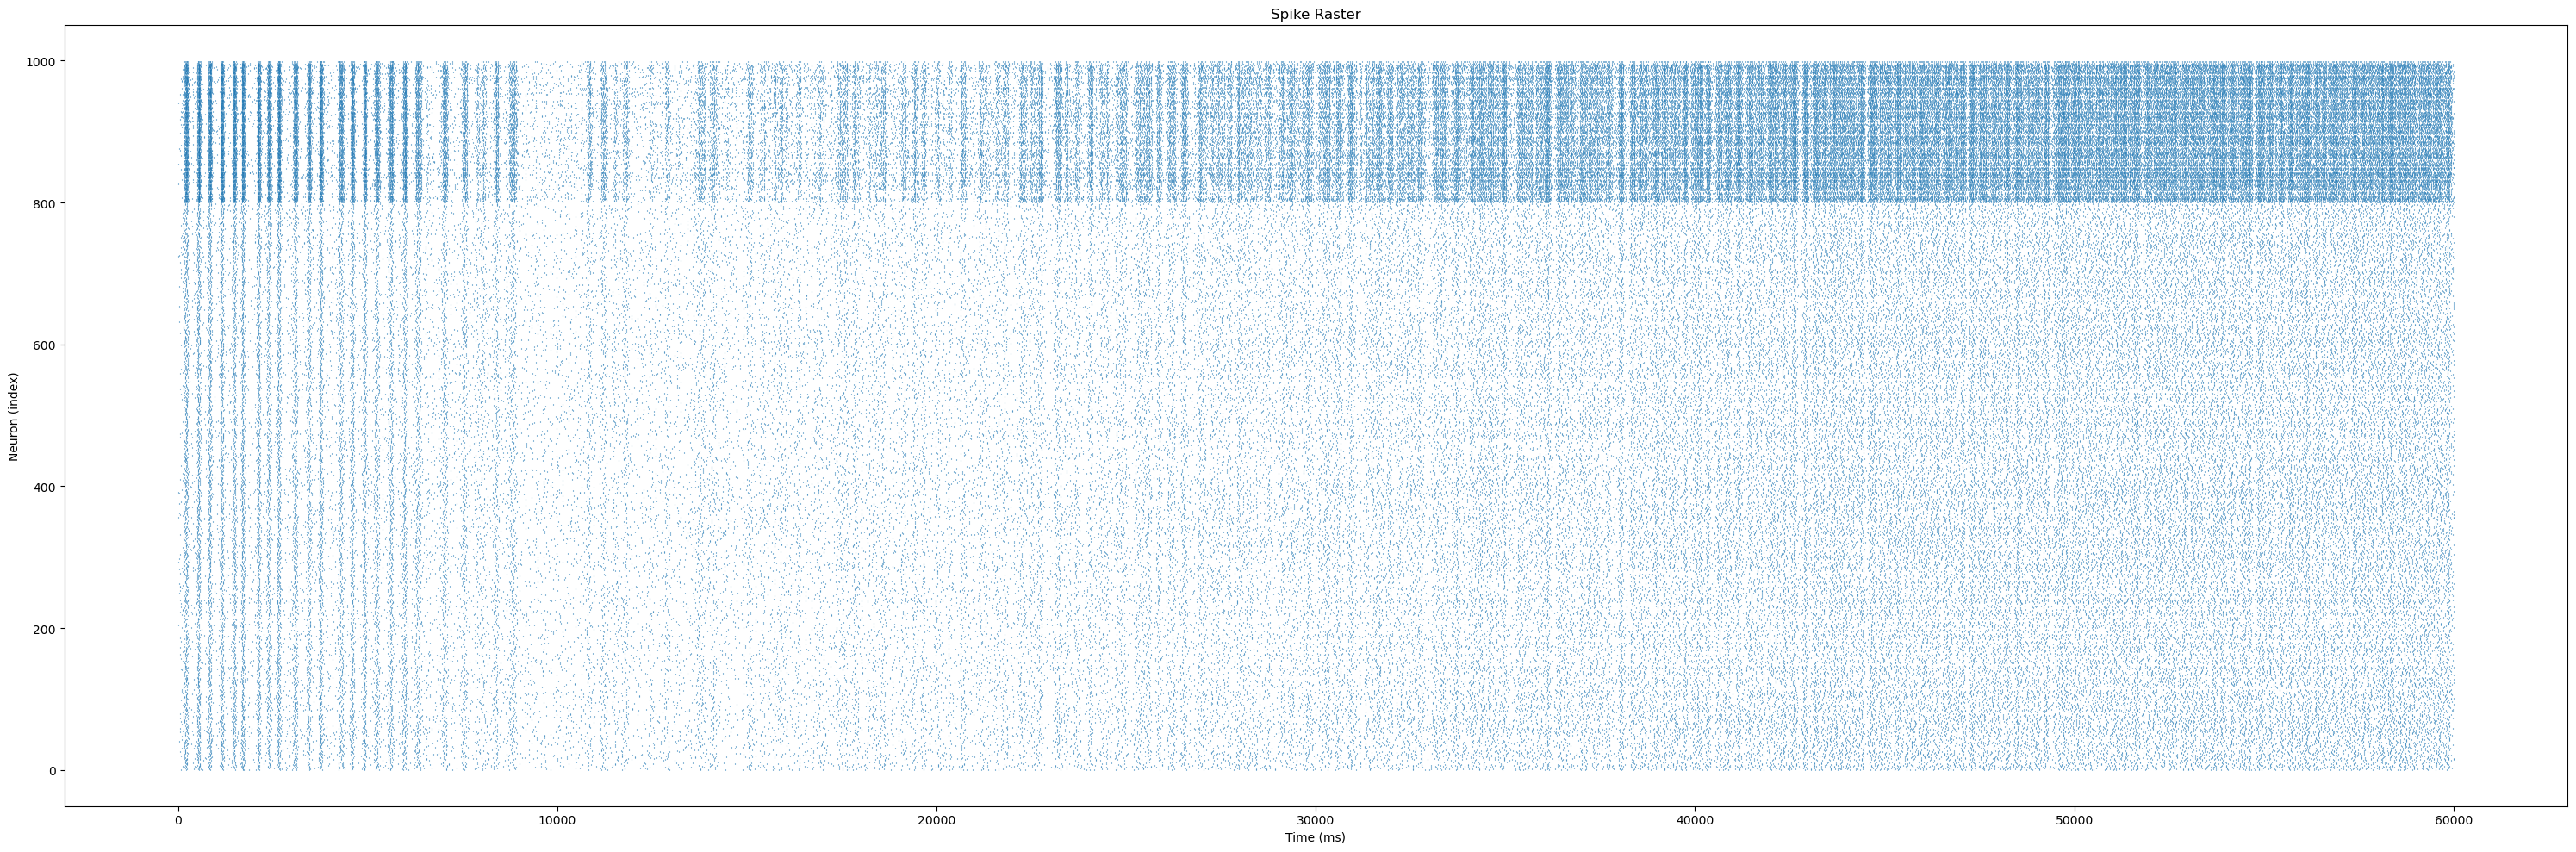

In [7]:
# We can collect the spikes manually
spike_list = sim.read_spikes()

# Plot this
plt.figure(figsize=(30,10))
plt.eventplot(spike_list, lineoffsets=1,linelengths=0.9,linewidths=0.8)
plt.title('Spike Raster')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron (index)')
plt.tight_layout()

In [8]:
# We can also read in the record information
record_list, record_index, record_data = sim.read_records()

record_list

Reading records is currently an experimental feature


[{'record_id': 0,
  'full_name': 'Izhi',
  'name': 'Izhi',
  'state': 'v',
  'period': 100.0},
 {'record_id': 1,
  'full_name': 'Izhi_1',
  'name': 'Izhi',
  'state': 'v',
  'period': 100.0},
 {'record_id': 2,
  'full_name': 'STDP_Izhi_Izhi',
  'name': 'STDP',
  'state': 'weight',
  'period': 1000.0},
 {'record_id': 3,
  'full_name': 'STDP_Izhi_Izhi_1',
  'name': 'STDP',
  'state': 'weight',
  'period': 1000.0}]

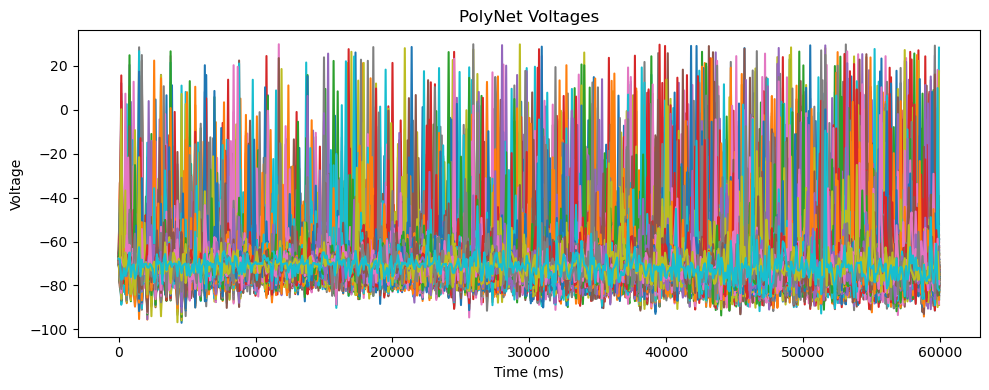

In [9]:
# This is the record information for membrane voltage
record_id = 0
record_times = np.array(list(record_data[record_id].keys()))
record_values = np.array(list(record_data[record_id].values()))

# We can then plot this data
plt.figure(figsize=(10,4))
plt.plot(record_times, record_values)
plt.title('PolyNet Voltages')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage')
plt.tight_layout()

[    0.  1000.  2000.  3000.  4000.  5000.  6000.  7000.  8000.  9000.
 10000. 11000. 12000. 13000. 14000. 15000. 16000. 17000. 18000. 19000.
 20000. 21000. 22000. 23000. 24000. 25000. 26000. 27000. 28000. 29000.
 30000. 31000. 32000. 33000. 34000. 35000. 36000. 37000. 38000. 39000.
 40000. 41000. 42000. 43000. 44000. 45000. 46000. 47000. 48000. 49000.
 50000. 51000. 52000. 53000. 54000. 55000. 56000. 57000. 58000. 59000.]
(60, 64000)
[('res_e[14]', 'res_e[0]'), ('res_e[21]', 'res_e[0]'), ('res_e[24]', 'res_e[0]'), ('res_e[56]', 'res_e[0]'), ('res_e[61]', 'res_e[0]'), ('res_e[72]', 'res_e[0]'), ('res_e[74]', 'res_e[0]'), ('res_e[97]', 'res_e[0]'), ('res_e[99]', 'res_e[0]'), ('res_e[105]', 'res_e[0]')]


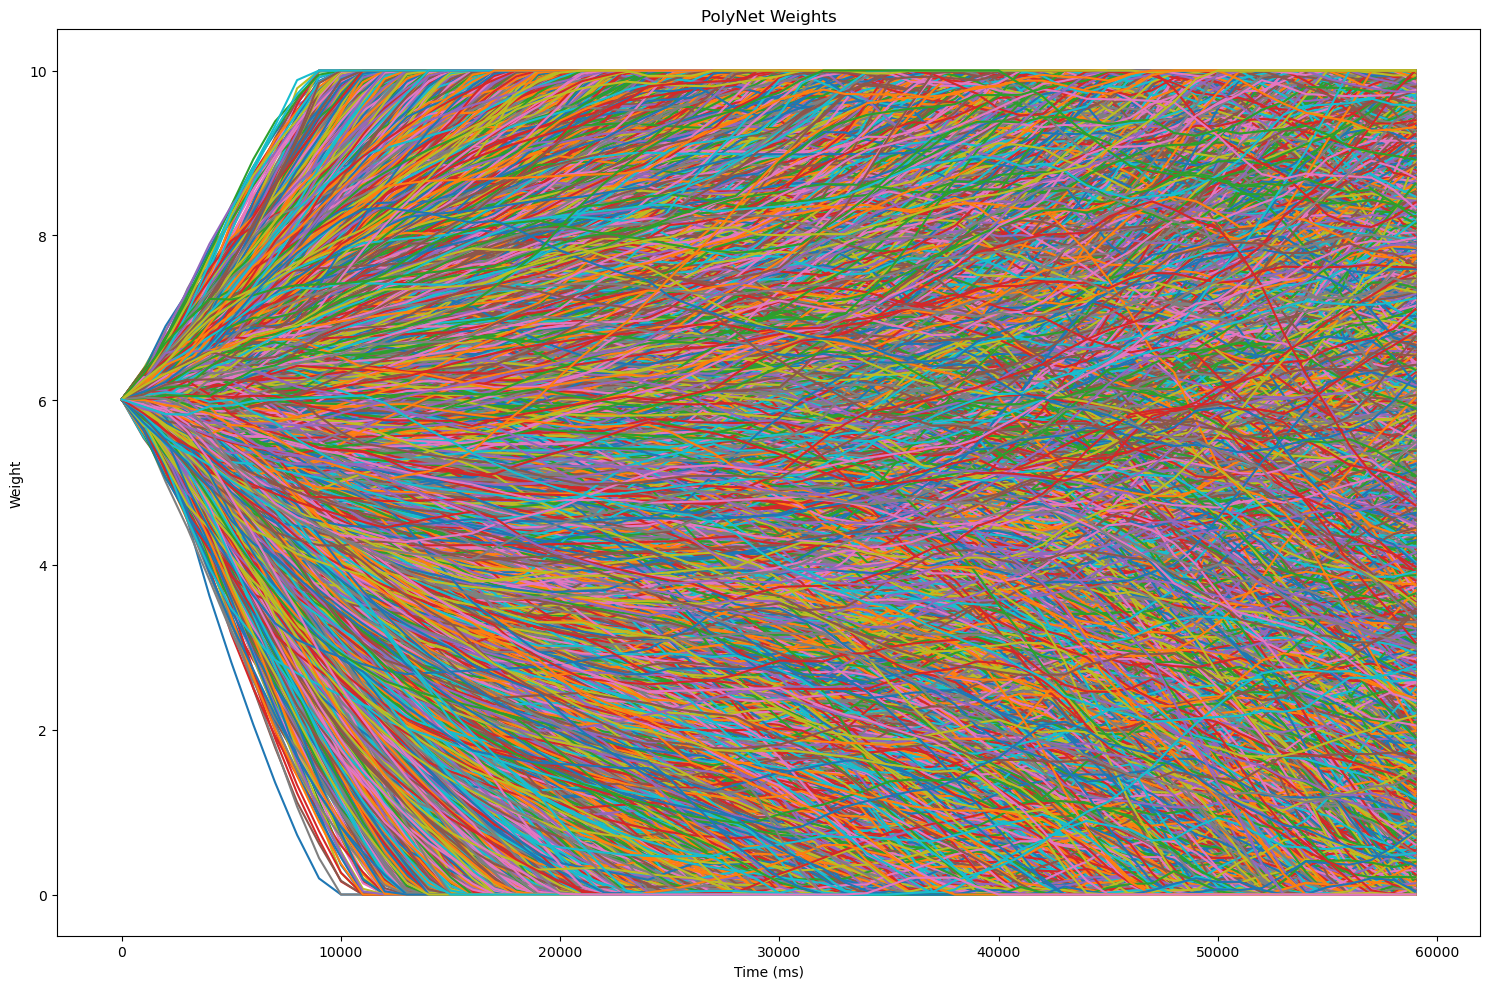

In [10]:
# This is the record information for excitatory to excitatory weights
record_id = 2
record_times = np.array(list(record_data[record_id].keys()))
record_values = np.array(list(record_data[record_id].values()))

# Printing some information about this
print(record_times)
print(record_values.shape)

# The ordering of the records is stored target-major
# with the index corresponding to the node map
index_map = [name for name in sim.node_map.keys()]
record_name = []
for target, sources in record_index[record_id].items():
    for source in sources:
        if source == -1: # nodes just use -1 for their source index
            record_name.append(index_map[target])
        else:
            record_name.append((index_map[source], index_map[target]))

# Print a few to show the names
print(record_name[:10])

# We can then plot this data
plt.figure(figsize=(15,10))
plt.plot(record_times, record_values)
plt.title('PolyNet Weights')
plt.xlabel('Time (ms)')
plt.ylabel('Weight')
plt.tight_layout()

In [11]:
# We can rename the checkpoint files:
# The default checkpoint extention is '.out'
# The default rename is '' (the initial state)
# If using non-defaults, the "extension" also needs
# to be updated. This is configured with 'file_ext'
sim.file_ext = '.60s'
sim.rename_checkpoint(sim.file_ext)

# We can also update other simulation configuration information
# Currently restricted to model params (no state information)
# This is still experimental (and not as well wrapped)
sim.update_param('Izhi', 'thal_rate', 0.2)
sim.update_param('STDP', 'A_pos', 0.0)
sim.update_param('STDP', 'A_neg', 0.0)
sim.update_param('STDP', 'wd_const', 0.0)
sim.update_param('STDP', 'wd_lambda', 0.0)
# sim.update_param('STDP', 'plastic', 0.0)

# Note: it is important not to "recompile" the network as
# that will overwrite the SNN-dCSR with the initial state
sim.write_yaml()

# Run the network for 10 seconds
sim.run(10000.0, verbose=True)

/Users/felwang/Documents/Projects/STACS/stacs/charmrun +p4 /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml

Running as 4 OS processes:  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
charmrun> mpirun -np 4  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
Charm++> Running on MPI version: 4.1
Charm++> level of thread support used: -1 (desired: 0)
Charm++> Running in non-SMP mode: 4 processes (PEs)
Converse/Charm++ Commit ID: v70000
Charm++ built without optimization.
Do not use for performance benchmarking (build with --with-production to do so).
Charm++ built with internal error checking enabled.
Do not use for performance benchmarking (build without --enable-error-checking to do so).
Isomalloc> Synchronized global address space.
CharmLB> Load balancer assumes all CPUs are same.
Charm++> Running on 1 hosts (1 sockets x 12 cores x 1 PUs = 12-way SMP)
Charm++> cpu topology info is gathered in 0.006 seconds.

Sim

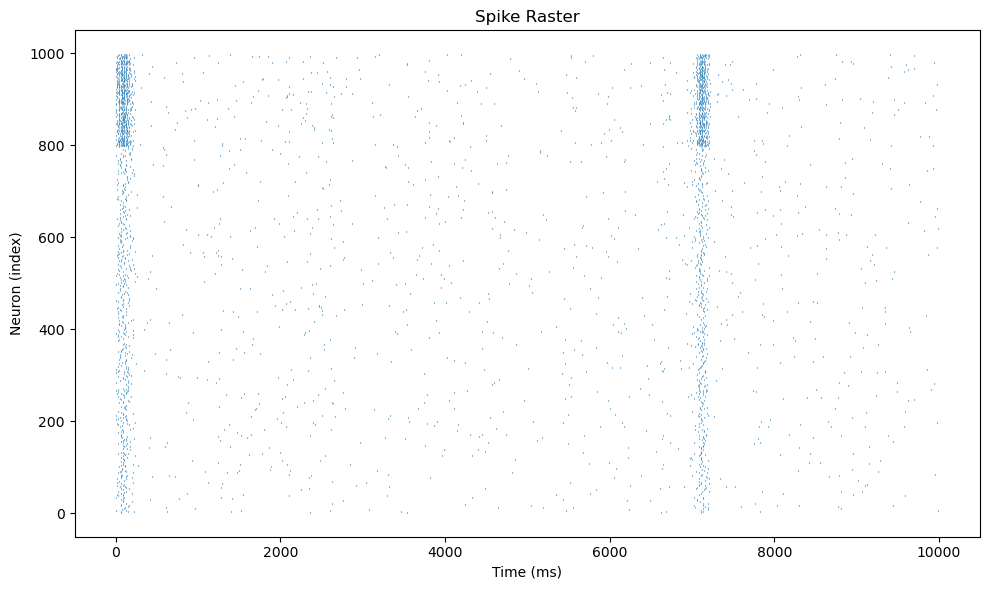

In [12]:
# We can collect the spikes again
spike_list = sim.read_spikes()

# Plot this
plt.figure(figsize=(10,6))
plt.eventplot(spike_list, lineoffsets=1,linelengths=0.9,linewidths=0.8)
plt.title('Spike Raster')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron (index)')
plt.tight_layout()

In [ ]:
# We can also read in the record information again
record_list, record_index, record_data = sim.read_records()

# This is the record information for excitatory to excitatory weights
record_id = 2
record_times = np.array(list(record_data[record_id].keys()))
record_values = np.array(list(record_data[record_id].values()))

# We can then plot this data (the weights are static this time)
plt.figure(figsize=(10,10))
plt.plot(record_times, record_values)
plt.title('PolyNet Weights')
plt.xlabel('Time (ms)')
plt.ylabel('Weight')
plt.tight_layout()

Reading records is currently an experimental feature
